## Predicting Lender Approval Decisions and Optimizing Broker Routing Using Machine Learning CASE STUDY 4
**Group Name**: Group 3

**Group Members**: Ebrima, Shivangi, Dayum, Ammar


## Executive Summary

This project is a supervised binary classification problem aimed at predicting lender-specific loan approval outcomes using customer financial features. The models will support an operational routing strategy designed to maximise first-time approvals, minimise failed applications, and reduce unnecessary credit checks while maintaining commercial viability.

## PHASE-1 Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


Mounted at /content/drive


In [2]:
car_df = pd.read_csv('/content/drive/My Drive/MS984_Car_Finance/prime_lender_dataset.csv')
#Quick description of datset, check number columns
car_df.head()


,applicant_age_years,gross_annual_income_gbp,current_employment_tenure_years,housing_status,credit_history_length_years,credit_utilisation_ratio,missed_payment_count_last_12_months,credit_applications_last_6_months,requested_loan_amount_gbp,debt_to_income_ratio,accepted_by_prime_lender,accepted_by_mid_prime_lender,accepted_by_stability_focused_lender
0,49.876985,61039.405698,4.965991,mortgage,22.812741,0.450701,0,2,7886.001244,0.465053,0,1,0
1,43.574196,22910.447246,6.403823,mortgage,17.882851,0.804988,3,4,11183.799619,0.803020,0,0,0
2,48.565680,37216.053708,12.060122,mortgage,17.174561,0.570877,4,3,1539.868216,0.439707,0,0,0
3,34.428966,42989.789876,9.449793,mortgage,10.739923,0.293865,2,1,15515.004052,0.418789,0,1,1
4,24.360958,24785.424893,9.797076,mortgage,1.376009,0.381306,1,0,8294.931587,0.480827,0,1,1


In [3]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   applicant_age_years                   20000 non-null  float64
 1   gross_annual_income_gbp               20000 non-null  float64
 2   current_employment_tenure_years       20000 non-null  float64
 3   housing_status                        20000 non-null  object 
 4   credit_history_length_years           20000 non-null  float64
 5   credit_utilisation_ratio              20000 non-null  float64
 6   missed_payment_count_last_12_months   20000 non-null  int64  
 7   credit_applications_last_6_months     20000 non-null  int64  
 8   requested_loan_amount_gbp             20000 non-null  float64
 9   debt_to_income_ratio                  20000 non-null  float64
 10  accepted_by_prime_lender              20000 non-null  int64  
 11  accepted_by_mid

In [4]:
car_df.describe()

,applicant_age_years,gross_annual_income_gbp,current_employment_tenure_years,credit_history_length_years,credit_utilisation_ratio,missed_payment_count_last_12_months,credit_applications_last_6_months,requested_loan_amount_gbp,debt_to_income_ratio,accepted_by_prime_lender,accepted_by_mid_prime_lender,accepted_by_stability_focused_lender
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.495597,43345.536352,8.009632,12.287651,0.502408,1.789100,1.988150,12948.607347,0.592032,0.191550,0.444050,0.375750
std,8.849010,18229.912558,4.438192,8.809506,0.223486,1.440495,1.514439,7874.537402,0.179356,0.393531,0.496872,0.484328
min,18.000000,12000.000000,0.000000,0.000000,0.016736,0.000000,0.000000,1000.000000,0.027240,0.000000,0.000000,0.000000
25%,33.088903,30482.943791,4.699454,5.056097,0.318438,1.000000,1.000000,7332.970800,0.457718,0.000000,0.000000,0.000000
50%,39.525212,39857.181510,7.661032,10.642040,0.504489,2.000000,2.000000,11422.522206,0.591687,0.000000,0.000000,0.000000
75%,45.865548,52436.395229,10.967654,18.080390,0.686893,3.000000,3.000000,16850.964608,0.726281,0.000000,1.000000,1.000000
max,68.762143,250000.000000,24.908093,48.111205,0.983872,6.000000,10.000000,60000.000000,1.153069,1.000000,1.000000,1.000000


In [5]:
car_df.shape

(20000, 13)

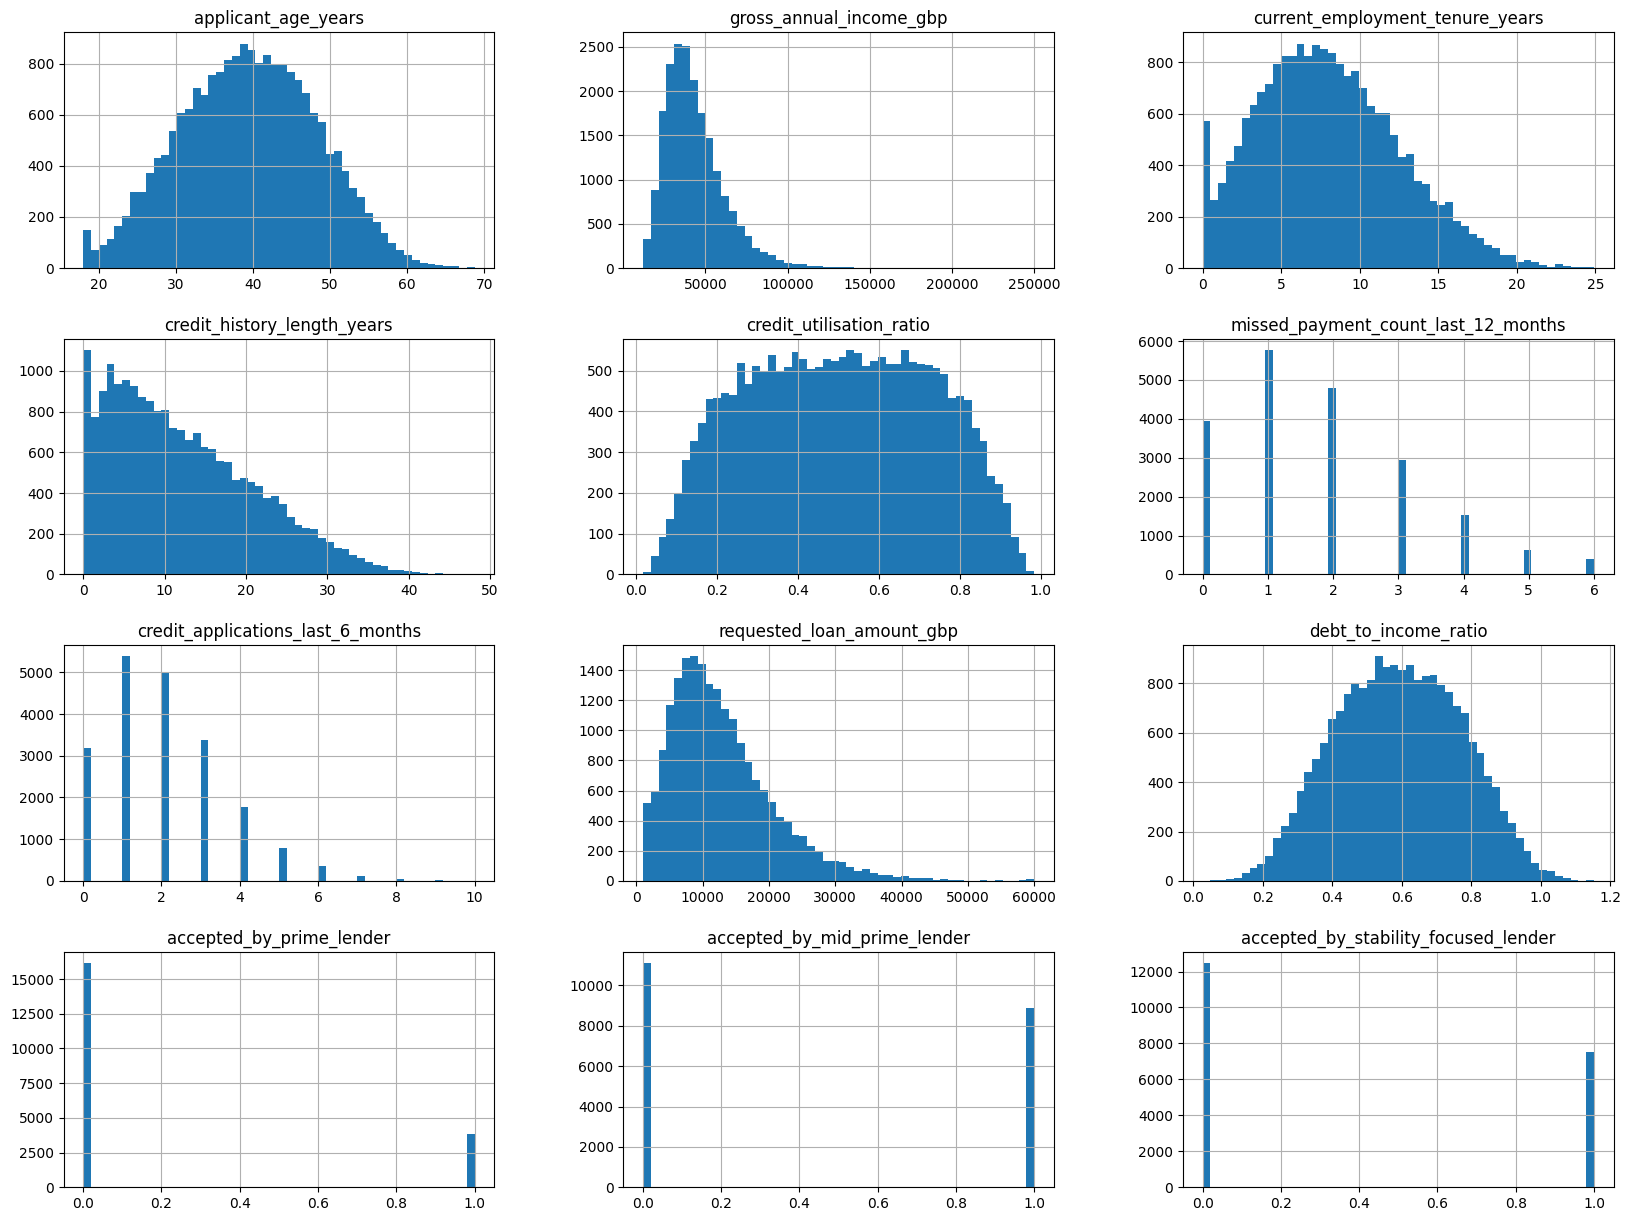

In [6]:
# Distribution of features
car_df.hist(bins=50, figsize=(20, 15))
plt.show()

**Feature Distribution Interpretation**

The feature distributions reveal several important characteristics about the borrower population. Applicant income is right-skewed, with most borrowers earning between £30,000 and £70,000 and a small number of higher-income outliers.

This indicates that the majority of applicants fall within a moderate income range, meaning income alone may not strongly differentiate borrower risk. Employment tenure is concentrated around 5 to 10 years, suggesting that many applicants demonstrate moderate employment stability, which can signal consistent income and financial reliability. Credit history length is also right-skewed, with many borrowers having relatively short credit histories while fewer have long-established credit records, implying that lenders may face greater uncertainty when evaluating borrowers with limited credit experience.

Credit utilisation ratios generally fall between 0.4 and 0.7 for many applicants, indicating moderate levels of credit usage, although values approaching 1 suggest heavy reliance on credit and potential financial stress. Missed payments are relatively low for most applicants, with the majority having between zero and two missed payments, while higher counts occur less frequently.

Loan requests are also right-skewed, with most applicants requesting loans between £5,000 and £20,000, and fewer requesting very large amounts. Overall, these distributions suggest that while income and employment stability provide useful background information, lenders are more likely to focus on behavioural risk indicators such as debt levels, credit utilisation, and payment history when assessing loan applications.

In [7]:
# To check for missing Values
car_df.isnull().sum()

,0
applicant_age_years,0
gross_annual_income_gbp,0
current_employment_tenure_years,0
housing_status,0
credit_history_length_years,0
credit_utilisation_ratio,0
missed_payment_count_last_12_months,0
credit_applications_last_6_months,0
requested_loan_amount_gbp,0
debt_to_income_ratio,0


In [8]:
# We check for Target Distribution
car_df["accepted_by_prime_lender"].mean()

np.float64(0.19155)

In [9]:
car_df["accepted_by_mid_prime_lender"].mean()


np.float64(0.44405)

In [10]:
car_df["accepted_by_stability_focused_lender"].mean()

np.float64(0.37575)

**Interpretation**

From our computed mean the prime lender is clearly the most selective, approving only about one in five applications.
The mid-prime lender has the highest approval rate, while the stability-focused lender falls in between.

**Business implication**

This confirms that lenders operate with different risk appetites, which justifies building separate predictive models for each lender.
For the broker, applications that appear risky for the prime lender may still have a reasonable chance of approval with mid-prime or stability-focused lenders. This supports the idea of intelligent routing strategies to maximise approval rates while minimising unnecessary credit checks.

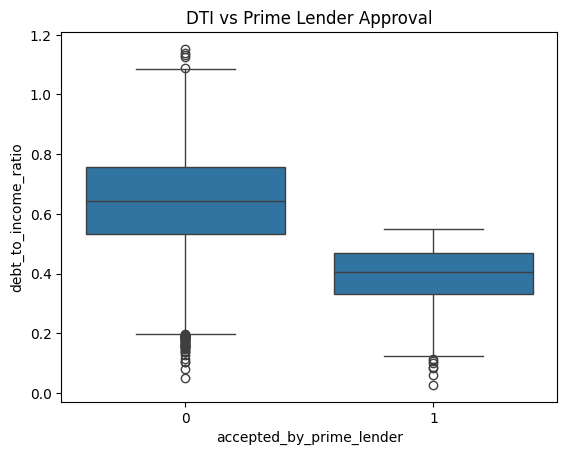

In [11]:
# We visualize DTI vs approval to see see if higher DTI leads to rejection.
sns.boxplot(x="accepted_by_prime_lender", y="debt_to_income_ratio", data=car_df)
plt.title("DTI vs Prime Lender Approval")
plt.show()

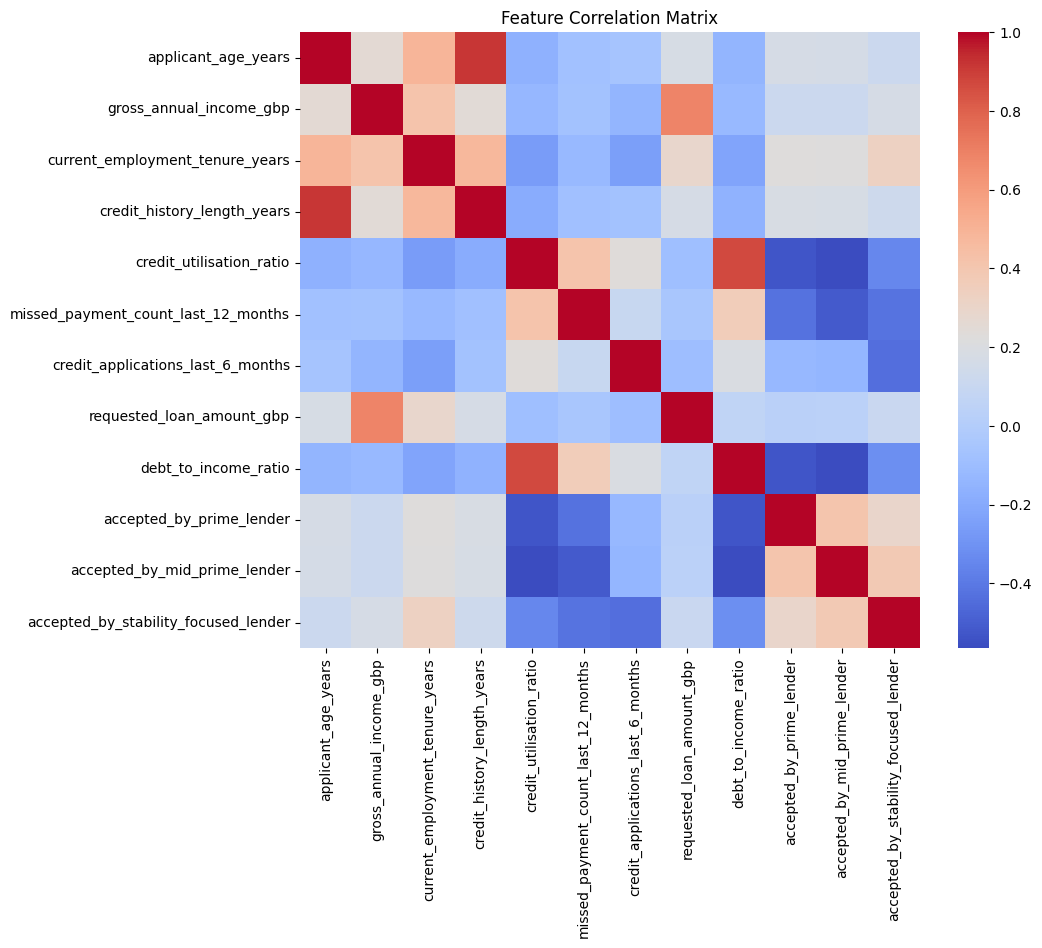

In [12]:
#We examine relationships between features. This help us to detect relationships between variables
plt.figure(figsize=(10,8))

sns.heatmap(
    car_df.drop(columns=["housing_status"]).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.show()

**Exploration Data Analysis Summary**

The exploratory data analysis provides valuable insights into lender behaviour and the factors that influence loan approval decisions. The target distribution shows that the prime lender has an approval rate of approximately 19%, indicating a highly selective lending strategy, while the mid-prime lender approves around 44% of applications and the stability-focused lender approves roughly 38%. These differences confirm that lenders operate with distinct risk tolerances, which justifies building separate predictive models for each lender.

 The correlation analysis further highlights relationships between key variables, such as the strong positive relationship between applicant age and credit history length, as well as the association between income and requested loan amounts. **More importantly, risk-related variables such as credit utilisation and debt-to-income ratio** show negative relationships with lender approvals, indicating that borrowers with higher leverage or greater credit dependence are more likely to be rejected.

  This pattern is further supported by the boxplot analysis comparing debt-to-income ratio with prime lender approval, which shows that rejected applications tend to have significantly higher DTI values than approved applications. Together, these findings suggest that the most influential predictors of lender decisions are d**ebt-to-income ratio, credit utilisation, and missed payment history**, as these variables directly capture **borrower financial stress and repayment behaviour**.
  
   From a business perspective, these insights support the use of predictive models to estimate lender acceptance probabilities and help the **broker route applications more intelligently to lenders whose risk preferences align with the borrower’s financial profile**, ultimately improving approval rates while reducing unnecessary credit checks.

##PHASE-2 DATA PREPARATION ##

In [13]:
# Encode Categorical Variabls
# our dataset contains one categorical variable, so we convert it to dummy variables
# and we drop the housing status because logistics regression requires avoiding dummy variable
car_df = pd.get_dummies(car_df, columns=["housing_status"], drop_first=True)

In [14]:
X = car_df.drop(columns=[
     "accepted_by_prime_lender",
     "accepted_by_mid_prime_lender",
    "accepted_by_stability_focused_lender"])

In [15]:
#Defining the target variables
y_prime = car_df[ "accepted_by_prime_lender"]
y_mid = car_df["accepted_by_mid_prime_lender"]
y_stability = car_df["accepted_by_stability_focused_lender"]

## Phase-3 TRAIN/TEST SPLIT ##

In [16]:
#We Split our dataset into X_train, X_test, y_train_prime, y_train_test
#we set aside 20% of the dataset for the testset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_prime, y_test_prime = train_test_split(X, y_prime, test_size= 0.2, random_state= 42, stratify= y_prime)

**Feature Scaling **

In [17]:
from pandas.core.tools.datetimes import Scalar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#we only fit the X_train
# and transform the x_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## PHASE-4 LOGISTICS REGRESSION

**LOGISTICS REGRESSION FOR PRIME LENDER**

In [18]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_prime)

LogisticRegression(max_iter=1000)

In [19]:
# We preidict the probabilites
y_probs = log_model.predict_proba(X_test_scaled)[:,1]

**Evaluate ROC-AUC**

In [20]:
# ROC_AUC It evaluates how well the model can separate two classes:(Accepted, Rejected)
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test_prime, y_probs)

print("Prime Lender ROC AUC:", roc_auc)

Prime Lender ROC AUC: 0.954027136608263


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

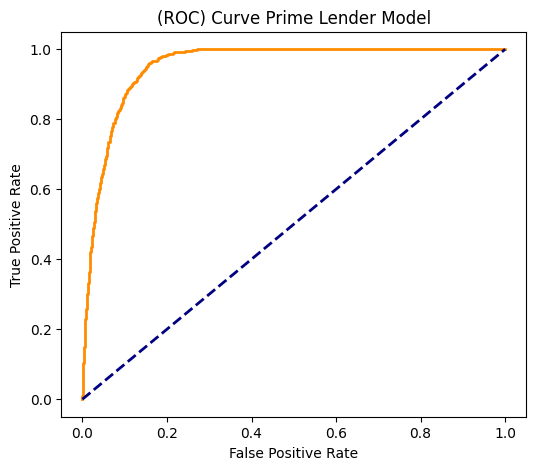

In [21]:
# Recall True Positive Rate (TPR)
# Out of all actual approvals, how many did the model correctly identify
#False Positive Rate (FPR) Out of all actual rejections, how many did the model incorrectly predict as approvals?
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_prime, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Logistic Regression ROC curve (AUC = 0.954)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve Prime Lender Model')
plt

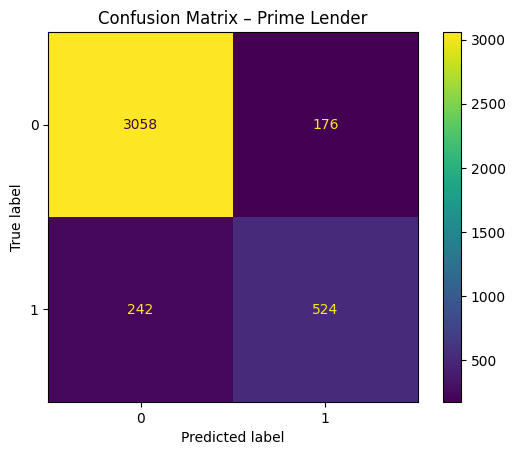

In [22]:
# Prime Lender confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (y_probs >= 0.5).astype(int)

cm = confusion_matrix(y_test_prime, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Prime Lender")
plt.show()

In [23]:

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

**LOGISTICS REGRESSION FOR MID PRIME**

In [24]:
X_train, X_test, y_train_mid, y_test_mid = train_test_split(
    X, y_mid, test_size=0.2, random_state=42, stratify=y_mid
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_mid = LogisticRegression(max_iter=1000)
log_mid.fit(X_train_scaled, y_train_mid)

y_probs_mid = log_mid.predict_proba(X_test_scaled)[:,1]

roc_auc_mid = roc_auc_score(y_test_mid, y_probs_mid)

print("ROC AUC Mid Prime:", roc_auc_mid)

ROC AUC Mid Prime: 0.8951862158921511


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

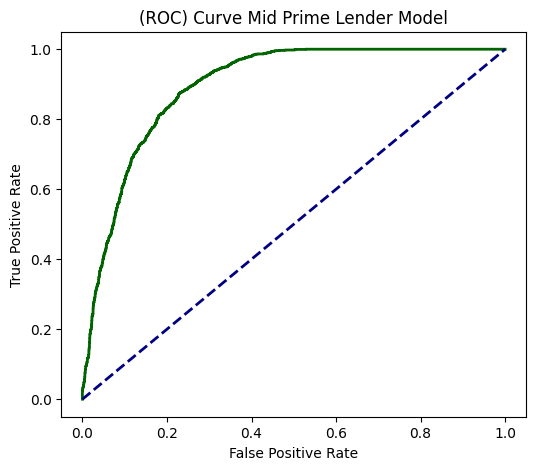

In [25]:
fpr, tpr, thresholds = roc_curve(y_test_mid, y_probs_mid)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label='Logistic Regression ROC curve (AUC = 0.0.895)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve Mid Prime Lender Model')
plt

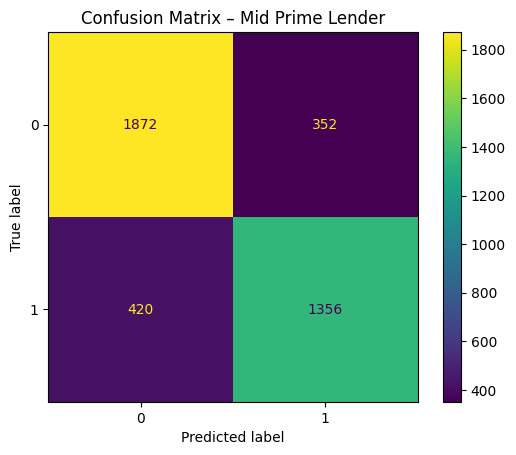

In [26]:
# Mid Prime Lender confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_mid = (y_probs_mid >= 0.5).astype(int)

cm = confusion_matrix(y_test_mid, y_pred_mid)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Mid Prime Lender")
plt.show()

 **LOGISTICS REGRESSION FOR STABIBILTY LENDER**

In [27]:
X_train, X_test, y_train_stab, y_test_stab = train_test_split(
    X, y_stability, test_size=0.2, random_state=42, stratify=y_stability
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_stab = LogisticRegression(max_iter=1000)
log_stab.fit(X_train_scaled, y_train_stab)

y_probs_stab = log_stab.predict_proba(X_test_scaled)[:,1]

roc_auc_stab = roc_auc_score(y_test_stab, y_probs_stab)

print("ROC AUC Stability:", roc_auc_stab)

ROC AUC Stability: 0.8893349331240069


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

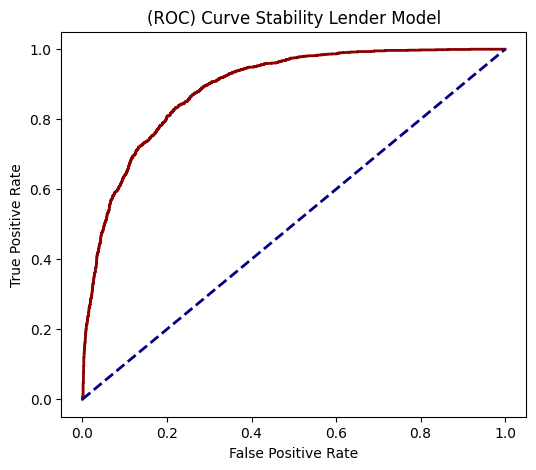

In [28]:
fpr, tpr, thresholds = roc_curve(y_test_stab, y_probs_stab)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkred', lw=2, label='Logistic Regression ROC curve (AUC = 0.0.889)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve Stability Lender Model')
plt

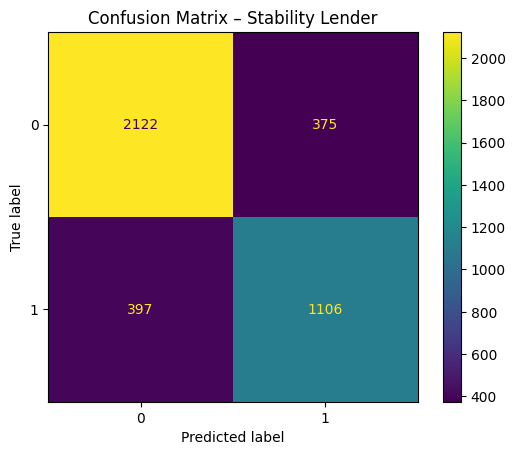

In [29]:
y_pred_stab = (y_probs_stab >= 0.5).astype(int)

cm = confusion_matrix(y_test_stab, y_pred_stab)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Stability Lender")
plt.show()

**Model Performance Comparison**
| Lender Model             | ROC-AUC Score | Model Performance Interpretation   |
| ------------------------ | ------------- | ---------------------------------- |
| Prime Lender             | **0.954**     | Excellent predictive performance   |
| Mid-Prime Lender         | **0.895**     | Very strong predictive performance |
| Stability-Focused Lender | **0.889**     | Very strong predictive performance |


**Interpretation**

The logistic regression models perform very well across all lenders. The prime lender model performs best, achieving an ROC-AUC of 0.954, indicating extremely strong ability to distinguish between approved and rejected applications. The mid-prime and stability models also show high predictive power, both achieving ROC-AUC values close to 0.90, which is generally considered strong classification performance.

 **Technical Explanation (For Data Science Audience)**

The ROC-AUC metric evaluates the ability of the model to distinguish between positive and negative classes across all possible classification thresholds. In this case, the models estimate the probability that a loan application will be accepted by each lender. The ROC curves demonstrate strong separation between accepted and rejected applications, particularly for the prime lender model where the curve approaches the top-left corner of the plot. This indicates high true positive rates while maintaining relatively low false positive rates.

The logistic regression model performs especially well for the prime lender because the acceptance criteria appear to follow relatively clear linear relationships with key financial risk indicators such as debt-to-income ratio, credit utilisation, and missed payment history. These variables strongly influence credit risk and therefore allow the model to effectively discriminate between high-risk and low-risk borrowers.

The mid-prime and stability lender models achieve slightly lower ROC-AUC values, suggesting that their acceptance criteria may involve more complex or less linear decision patterns. However, both models still demonstrate strong predictive ability and remain suitable baseline models for explaining lender approval behaviour.

**Non-Technical Explanation (For Business Stakeholders)**

The predictive models perform very well at identifying which customers are likely to be approved or rejected by each lender. The results show that the model for the prime lender is particularly accurate, correctly distinguishing approved and rejected applications most of the time. The models for the mid-prime and stability lenders are also highly reliable.

In simple terms, this means the system can effectively estimate the likelihood that a customer will be approved by a specific lender before submitting the application. This capability can help the broker make better routing decisions, sending applications to lenders where approval is more likely. As a result, the broker can increase first-time approvals, reduce unnecessary credit checks, and improve the overall customer experience.

**Section Conclusion (Baseline Model Summary)**

The logistic regression baseline models demonstrate strong predictive performance across all lenders, particularly for the prime lender where approval patterns appear highly structured. These results confirm that borrower financial indicators such as debt levels, credit utilisation, and payment history contain sufficient predictive information to model lender decisions. The baseline models therefore provide a useful benchmark for understanding lender approval behaviour before introducing more advanced machine learning models.

## PHASE-5 HISTBOOSTING MODEL

**BOOSTING MODEL FOR PRIME LENDER**

In [30]:
# Train Model
from sklearn.ensemble import HistGradientBoostingClassifier
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_prime, test_size=0.2, random_state=42, stratify=y_prime
)

boost_prime = HistGradientBoostingClassifier(random_state=42)

boost_prime.fit(X_train_p, y_train_p)
y_probs_boost_prime = boost_prime.predict_proba(X_test_p)[:,1]

In [31]:
#Evaluate ROC AUC
from sklearn.metrics import roc_auc_score

roc_auc_boost_prime = roc_auc_score(y_test_p, y_probs_boost_prime)

print("Boosted ROC AUC (Prime):", roc_auc_boost_prime)

Boosted ROC AUC (Prime): 0.9754485226324092


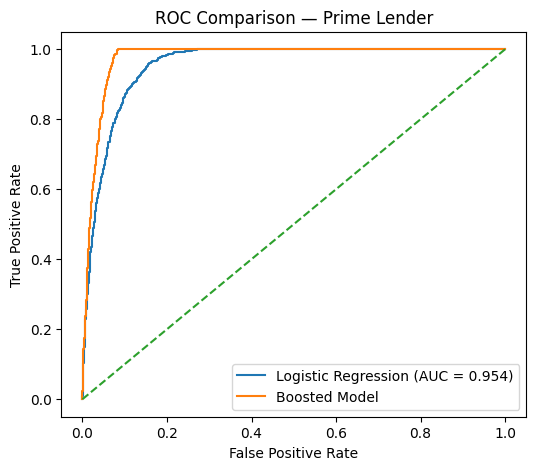

In [32]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test_prime, y_probs)
fpr_boost, tpr_boost, _ = roc_curve(y_test_prime, y_probs_boost_prime)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression (AUC = 0.954)")
plt.plot(fpr_boost, tpr_boost, label="Boosted Model")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — Prime Lender")

plt.legend()
plt.show()

**BOOSTING MODEL FOR MID LENDER`**

In [33]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_mid, test_size=0.2, random_state=42, stratify=y_mid
)

boost_mid = HistGradientBoostingClassifier(random_state=42)

boost_mid.fit(X_train_m, y_train_m)
y_probs_boost_mid = boost_mid.predict_proba(X_test_m)[:,1]
roc_auc_boost_mid = roc_auc_score(y_test_m, y_probs_boost_mid)

print("Boosted ROC AUC (Mid):", roc_auc_boost_mid)

Boosted ROC AUC (Mid): 0.9258880902035129


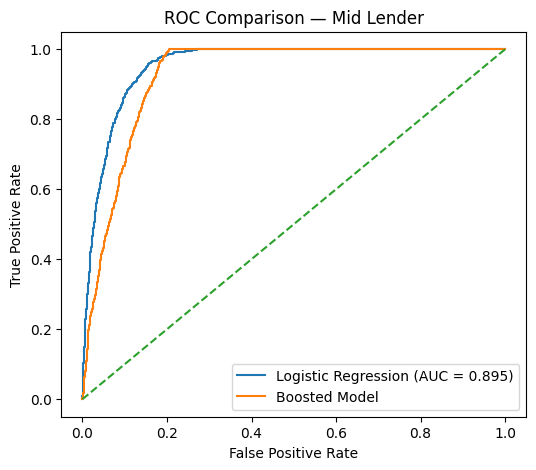

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_mid, y_probs_mid)
fpr_boost, tpr_boost, _ = roc_curve(y_test_m, y_probs_boost_mid)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression (AUC = 0.895)")
plt.plot(fpr_boost, tpr_boost, label="Boosted Model")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — Mid Lender")

plt.legend()
plt.show()

**BOOSTING MODEL FOR STABILITY LENDER**

In [35]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_stability, test_size=0.2, random_state=42, stratify=y_stability
)


boost_stability = HistGradientBoostingClassifier(random_state=42)

boost_stability.fit(X_train_s, y_train_s)
y_probs_boost_s = boost_stability.predict_proba(X_test_s)[:,1]
roc_auc_boost_stability = roc_auc_score(y_test_s, y_probs_boost_s)

print("Boosted ROC AUC (Stability):", roc_auc_boost_stability)

Boosted ROC AUC (Stability): 0.921430533673009


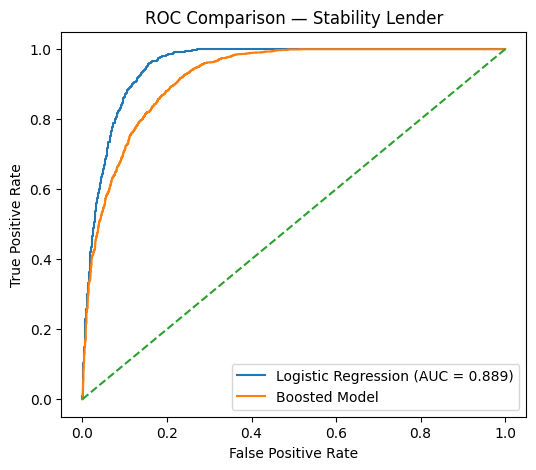

In [36]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_stab, y_probs_stab)
fpr_boost, tpr_boost, _ = roc_curve(y_test_s, y_probs_boost_s)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression (AUC = 0.889)")
plt.plot(fpr_boost, tpr_boost, label="Boosted Model")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison — Stability Lender")

plt.legend()
plt.show()

In [37]:
comparison_table = pd.DataFrame({
    "Lender": ["Prime", "Mid", "Stability"],
    "Logistic ROC-AUC": [0.954027136608263, 0.8951862158921511, 0.8893349331240069],
    "Boosted ROC-AUC": [0.9754485226324092, 0.9258880902035129, 0.921430533673009]
})

comparison_table["Improvement"] = comparison_table["Boosted ROC-AUC"] - comparison_table["Logistic ROC-AUC"]

comparison_table.round(3)

,Lender,Logistic ROC-AUC,Boosted ROC-AUC,Improvement
0,Prime,0.954,0.975,0.021
1,Mid,0.895,0.926,0.031
2,Stability,0.889,0.921,0.032


**Interpretation**

The boosted model improves predictive performance for all lenders. The largest improvements occur for the mid-prime and stability lenders, suggesting that their approval behaviour may involve more complex patterns that logistic regression cannot fully capture.

**Technical Explanation**

The improved performance of the HistGradientBoosting model is expected because boosting algorithms can model non-linear relationships and interactions between variables, whereas logistic regression assumes a linear relationship between the input variables and the log-odds of the outcome.

For example, lending decisions may not change smoothly as a variable increases. Instead, lenders may apply threshold-based decision rules. A borrower with a debt-to-income ratio below a certain level may be acceptable, but once the ratio exceeds a specific threshold the likelihood of rejection increases sharply. Logistic regression cannot naturally capture these abrupt changes, whereas gradient boosting can model them using decision tree splits.

Boosting also improves performance by sequentially building trees that correct the prediction errors of previous trees, allowing the model to capture more subtle patterns in the data. This enables the algorithm to detect interactions between variables such as credit utilisation, debt-to-income ratio, and missed payment history.

**Feature Importance Discussion**

**This where we answer Task 1A the discussion part**

The improved performance of the boosted model suggests that interactions between financial risk indicators influence lender decisions.

Possible examples include:

High DTI combined with high credit utilisation may strongly increase rejection probability.

Short credit history combined with multiple recent credit applications may signal higher borrower risk.

Stable employment combined with low missed payments may significantly increase approval probability.

**Boosted Model Section Summary**

The boosted models demonstrate clear performance improvements compared with the logistic regression baseline. While logistic regression provides strong interpretability and serves as a useful benchmark, the boosting algorithm better captures complex relationships between borrower characteristics and lender approval decisions. These results suggest that ensemble models may provide more accurate predictions for loan approval probability in real-world brokerage systems.

## Phase-6: Task 2 — Identifying Lender Hard Rules

**Bin Key Risk Variables**

In [38]:
car_df["DTI_bin"] = pd.cut(
    car_df["debt_to_income_ratio"],
    bins=[0,0.3,0.5,0.7,1.2],
    labels=["Low","Moderate","High","Very High"]
)

**Prime Lender DTI Hard Rule**

In [39]:
#Acceptance Rate by DTI
car_df.groupby("DTI_bin")["accepted_by_prime_lender"].mean()

/tmp/ipykernel_552/1431597877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_df.groupby("DTI_bin")["accepted_by_prime_lender"].mean()


,accepted_by_prime_lender
DTI_bin,
Low,0.656535
Moderate,0.473818
High,0.076031
Very High,0.000000


/tmp/ipykernel_552/2712399552.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_df.groupby("DTI_bin")["accepted_by_prime_lender"].mean().plot(kind="bar")


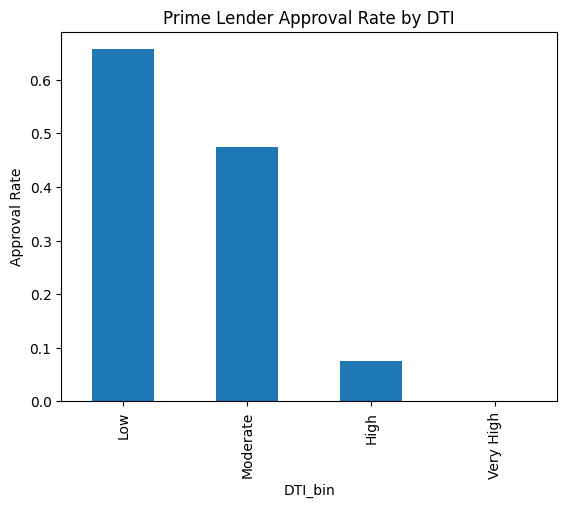

In [40]:
car_df.groupby("DTI_bin")["accepted_by_prime_lender"].mean().plot(kind="bar")
plt.title("Prime Lender Approval Rate by DTI")
plt.ylabel("Approval Rate")
plt.show()

/tmp/ipykernel_552/4076975033.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  prime_matrix = car_df.pivot_table(


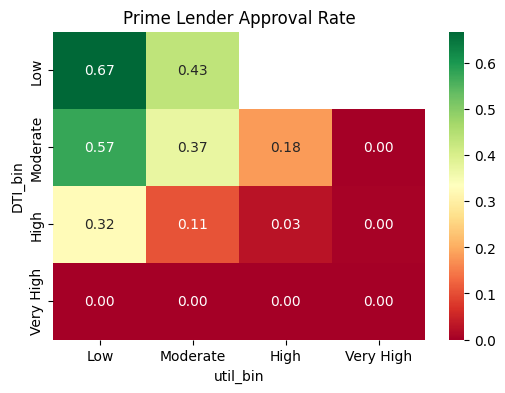

In [51]:
prime_matrix = car_df.pivot_table(
    values="accepted_by_prime_lender",
    index="DTI_bin",
    columns="util_bin",
    aggfunc="mean"
)

plt.figure(figsize=(6,4))
sns.heatmap(prime_matrix, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Prime Lender Approval Rate")
plt.show()

**Interpretation**

Approval probability drops dramatically as DTI increases.
Once the DTI enters the “High” category (>0.7), approval falls to only ~7%, and when it becomes Very High (>0.9) the approval rate is 0%.

**Rule Defination**

 If Debt-to-Income Ratio > 0.7 → very high probability of rejection
If Debt-to-Income Ratio > 0.9 → near certain rejection

**Business Meaning**

The prime lender appears to enforce a strict leverage threshold, where borrowers already carrying high debt relative to income are considered too risky to approve.

**Prime Lender Credit Utilization Hard Rule**

In [43]:
#Credit Utilisation Rule
car_df["util_bin"] = pd.cut(
    car_df["credit_utilisation_ratio"],
    bins=[0,0.3,0.5,0.7,1],
    labels=["Low","Moderate","High","Very High"]
)

In [52]:
car_df.groupby("util_bin")["accepted_by_prime_lender"].mean()

/tmp/ipykernel_552/957559936.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_df.groupby("util_bin")["accepted_by_prime_lender"].mean()


,accepted_by_prime_lender
util_bin,
Low,0.563636
Moderate,0.214219
High,0.024845
Very High,0.000431


**Interpretation**

Approval probability drops sharply as credit utilisation increases.
When utilisation becomes high (>0.7), approval falls to around 2%, and when it is very high (>0.9) approvals are almost nonexistent.

**Hard Rule Identified**

If credit utilisation > 0.7 → very high probability of rejection
If credit utilisation > 0.9 → near certain rejection

**Business Meaning**

The lender appears to penalize borrowers who are already using a large proportion of their available credit. High credit utilisation signals financial stress and heavy reliance on credit, which increases the perceived risk of default.

**Prime Lender missed_payment_count_last_12_months Rule**

In [44]:
#Missed Payment Rule
car_df.groupby("missed_payment_count_last_12_months")["accepted_by_prime_lender"].mean()

,accepted_by_prime_lender
missed_payment_count_last_12_months,
0,0.464975
1,0.346447
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000


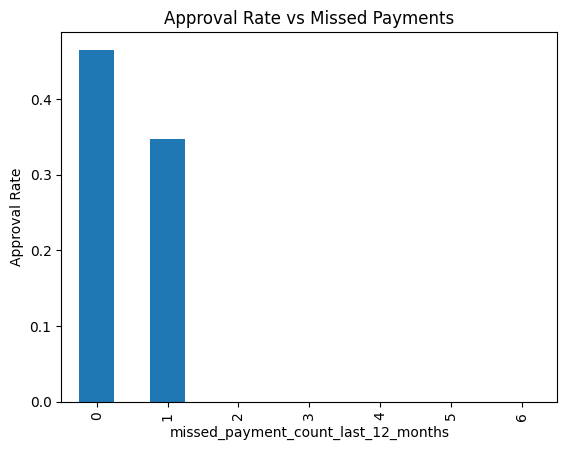

In [45]:
car_df.groupby("missed_payment_count_last_12_months")["accepted_by_prime_lender"].mean().plot(kind="bar")
plt.title("Approval Rate vs Missed Payments")
plt.ylabel("Approval Rate")
plt.show()

**Interpretation**

Approval probability drops sharply once missed payments increase.
When borrowers have two or more missed payments in the last 12 months, the approval rate becomes 0%, indicating automatic rejection.

**Hard Rule Identified**

If missed payments ≥ 2 in the last 12 months → automatic rejection

**Business Meaning**

The prime lender appears to enforce a strict repayment reliability rule.
Borrowers with multiple recent missed payments are considered too risky because missed payments directly signal poor repayment behaviour.

**Decision Tree fpr Hard Rules**

In [46]:
# Validate with a Small Decision Tree
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3)

tree.fit(X, y_prime)

DecisionTreeClassifier(max_depth=3)

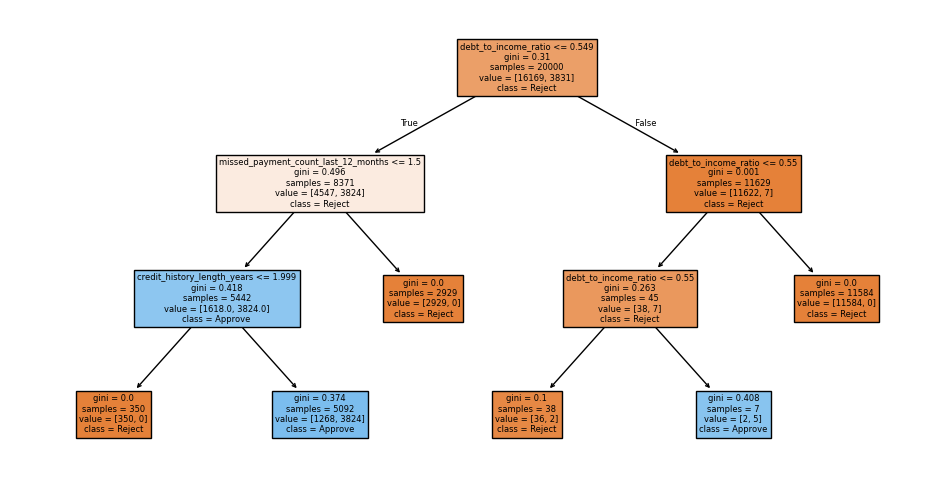

In [47]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=X.columns, class_names=["Reject","Approve"], filled=True)
plt.show()

**Mid-Lender Hard Rule**

/tmp/ipykernel_552/2709394605.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mid_matrix = car_df.pivot_table(


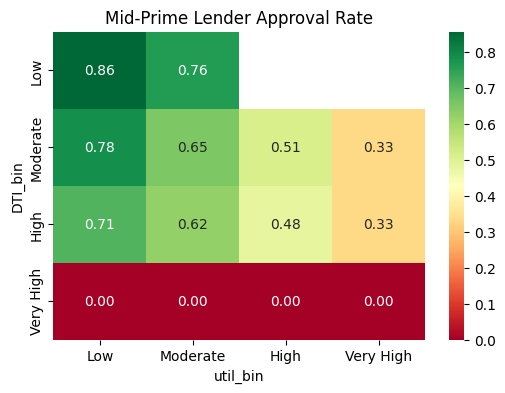

In [48]:
mid_matrix = car_df.pivot_table(
    values="accepted_by_mid_prime_lender",
    index="DTI_bin",
    columns="util_bin",
    aggfunc="mean"
)

plt.figure(figsize=(6,4))
sns.heatmap(mid_matrix, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Mid-Prime Lender Approval Rate")
plt.show()

**Mid Lender DTI Rule 1**

When DTI is Very High, approval drops to 0% regardless of utilisation.
If DTI > ~0.9 → rejection

**Reasoning**

Even though the mid-prime lender is more flexible than the prime lender, extremely leveraged borrowers are still rejected.

**Rule 2**

If missed payments ≥ 3 → automatic rejection

**Reasoning**

The mid-prime lender tolerates slightly worse repayment behaviour than the prime lender but still rejects applicants with multiple recent missed payments.

**Stability Lender Hard Rule**

/tmp/ipykernel_552/2682422111.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  stab_matrix = car_df.pivot_table(


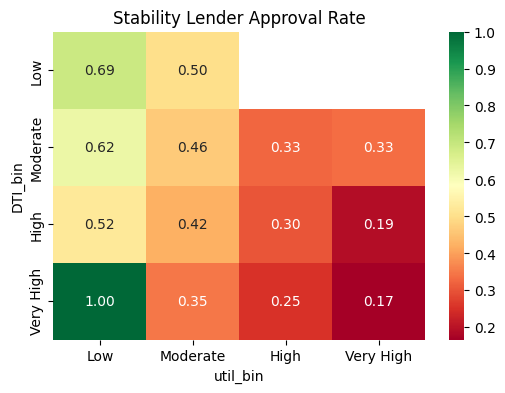

In [49]:
stab_matrix = car_df.pivot_table(
    values="accepted_by_stability_focused_lender",
    index="DTI_bin",
    columns="util_bin",
    aggfunc="mean"
)

plt.figure(figsize=(6,4))
sns.heatmap(stab_matrix, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Stability Lender Approval Rate")
plt.show()

**Rule 1 Missed Payments**

If missed payments ≥ 3 → automatic rejection

**Reasoning**

Even flexible lenders still require minimum repayment reliability.

**Rule 2 — Combined High Risk Rule(DTI & Credit Utilization**

From the heatmap:

When DTI is High AND utilisation is Very High, approval rates fall to around 17–19%, indicating strong rejection probability.

**Rule**

If DTI is high and credit utilisation is very high → high rejection probability

**Reasoning**

The stability lender tolerates higher leverage than other lenders but still penalizes borrowers who are both highly leveraged and heavily reliant on credit.

In [50]:
missed_payment_rules = car_df.groupby("missed_payment_count_last_12_months")[[
    "accepted_by_prime_lender",
    "accepted_by_mid_prime_lender",
    "accepted_by_stability_focused_lender"
]].mean()

missed_payment_rules

,accepted_by_prime_lender,accepted_by_mid_prime_lender,accepted_by_stability_focused_lender
missed_payment_count_last_12_months,,,
0,0.464975,0.710152,0.561168
1,0.346447,0.620797,0.527036
2,0.000000,0.521694,0.472048
3,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000


**Lender Hard Rules Summary**

The analysis of borrower characteristics reveals several strong decision patterns used by the prime lender when evaluating loan applications. Approval probabilities decline sharply when borrowers exhibit higher levels of financial leverage or signs of repayment risk. In particular, borrowers with debt-to-income ratios above approximately 0.7 experience a substantial drop in approval probability, with near-certain rejection when the ratio exceeds 0.9.

Similarly, applicants with two or more missed payments in the previous 12 months are consistently rejected, indicating a strict rule regarding repayment reliability. Credit utilisation also appears to play a significant role in the lender’s decision-making process, with approval rates declining rapidly as utilisation increases and becoming nearly zero when utilisation exceeds 0.9.

These patterns suggest that the prime lender applies strict thresholds on borrower leverage and payment behaviour, prioritizing financially stable applicants with low debt burdens and strong repayment histories.

**Routing Strategic for Brooker**

These decision base profile enables the brooker strategize how loan applications should be routed strategically based on borrower risk characteristics, enabling brokers to match applicants with lenders whose approval criteria best align with their financial profile.

| Borrower Profile                                  | Best Lender          |
| ------------------------------------------------- | -------------------- |
| Low DTI + low utilisation + clean payment history | **Prime lender**     |
| Moderate DTI or moderate utilisation              | **Mid-prime lender** |
| High DTI but stable repayment behaviour           | **Stability lender** |
